In [24]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 텍스트 탐색용
import re
from collections import Counter

# 머신러닝 (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from lightgbm import LGBMClassifier # 베이스라인의 XGBoost를 쓰셔도 됩니다.
from xgboost import XGBClassifier
# 희소 행렬(sparse matrix) 타입 확인용
from scipy import sparse

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Windows 기준: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

#plt 그래프 스타일 설정
plt.style.use("ggplot")

# 노트북 안에서 그래프가 바로 보이도록 설정
%matplotlib inline

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [25]:
# ---- 파일 경로 설정 ----
# 노트북과 같은 폴더에 있는 파일명을 기준으로 경로를 설정합니다.
# 파일을 다른 폴더에 저장했거나 파일명이 다르면, 아래 값을 실제 파일 위치에 맞게 수정합니다.
# 이후 코드들은 파일명을 직접 쓰지 않고 이 변수들을 사용하므로, 경로 변경은 이 셀만 수정하면 됩니다.
TRAIN_PATH = "security_log_train.csv"             # 학습 데이터 (로그 텍스트 + 정답 level)
TEST_PATH = "security_log_test.csv"               # 테스트 데이터 (정답 level 없음)
SAMPLE_SUBMISSION_PATH = "sample_submission.csv"  # 제출 양식
OUTPUT_PATH = "submission.csv"                     # 생성할 제출 파일

# ---- 실행 옵션 ----
# RANDOM_STATE: 결과 재현성을 위한 난수 시드입니다.
# 같은 시드를 사용하면 train/valid 분리나 모델 학습 결과가 매번 동일하게 재현됩니다.
RANDOM_STATE = 42

print("설정 완료 (전체 train 데이터를 사용합니다)")

설정 완료 (전체 train 데이터를 사용합니다)


In [26]:
# 위에서 정의한 경로 변수를 사용해 세 개의 데이터를 불러옵니다.
# train: 모델이 학습할 로그 텍스트(full_log)와 정답 라벨(level)이 들어 있습니다.
# test : 예측 대상 데이터입니다. 정답 level이 없으므로 우리가 예측해서 채웁니다.
# sample_submission: 제출 파일의 형식(행 개수, 컬럼)을 알려주는 양식입니다.
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

# 각 데이터의 행/열 개수를 확인합니다. (train과 test의 행 개수는 보통 다릅니다.)
print("train shape:", train.shape)
print("test shape :", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (472972, 3)
test shape : (1418916, 2)
sample_submission shape: (1418916, 2)


In [27]:
# level이 "0", "1"처럼 문자열 숫자로 저장돼 있을 수도 있으므로 정수형으로 변환합니다.
# XGBoost 다중분류는 라벨이 0부터 시작하는 정수일 때 가장 안전하게 동작합니다.
# (이미 정수면 값은 그대로 유지됩니다. 별도의 LabelEncoder가 필요하지 않습니다.)
train["level"] = train["level"].astype(int)

# 실제 라벨 목록과, 0부터 시작하는 연속 정수라는 예상 라벨을 비교할 준비를 합니다.
unique_levels = sorted(train["level"].unique())
expected_levels = list(range(len(unique_levels)))

print("level dtype:", train["level"].dtype)
print("실제 level 목록:", unique_levels)
print("예상 level 목록:", expected_levels)

# 라벨이 0, 1, 2, ... 처럼 연속된 정수가 아니면 학습 결과가 어긋날 수 있습니다.
# 이런 경우 경고만 출력하고 넘어가면 잘못된 라벨로 학습하게 되므로,
# ValueError로 실행을 멈춰서 데이터를 먼저 확인하도록 합니다.
if unique_levels != expected_levels:
    raise ValueError(
        f"level 라벨이 0부터 시작하는 연속 정수가 아닙니다. "
        f"현재 라벨: {unique_levels}. 대회 데이터 설명을 확인하세요."
    )
else:
    print(f"확인 완료: level 라벨은 0부터 시작하는 연속 정수입니다. {unique_levels}")

level dtype: int64
실제 level 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
예상 level 목록: [0, 1, 2, 3, 4, 5, 6]
확인 완료: level 라벨은 0부터 시작하는 연속 정수입니다. [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [ ]:
train_length = train.copy()
# 로그 길이 컬럼 만들기 (탐색용)
train_length["log_length"] = train_length["full_log"].str.len()
test_length["log_length"] = test_length["full_log"].str.len()

print("[train 로그 길이 통계]")
print(train_length["log_length"].describe())

[train 로그 길이 통계]
count    472972.000000
mean        473.361624
std         317.267954
min           7.000000
25%         204.000000
50%         423.000000
75%         689.000000
max       64106.000000
Name: log_length, dtype: float64


In [ ]:
# 입력(X)과 정답(y)을 정의합니다. baseline은 오직 full_log 텍스트만 입력으로 사용합니다.
X = train_length[["full_log", "log_length"]]
y = train_length["level"]

# 학습용(train)과 검증용(valid)으로 나눕니다.
# - test_size=0.2: 전체의 20%를 검증용으로 떼어 둡니다. (모델이 보지 않은 데이터로 성능 확인)
# - stratify=y: 분리 전후의 level 비율을 비슷하게 유지합니다.
#   클래스 불균형이 심한 데이터에서 stratify를 쓰지 않으면, 희귀 level이 한쪽에만 몰려
#   검증 점수를 신뢰하기 어려워질 수 있습니다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print()
print("[검증 데이터 level 분포]")
print(y_valid.value_counts().sort_index())

X_train: (378377, 2)
X_valid: (94595, 2)

[검증 데이터 level 분포]
level
0    66813
1    26504
2        2
3      828
4        2
5      444
6        2
Name: count, dtype: int64


In [30]:
labels_sorted = sorted(train['level'].unique())
num_classes = len(labels_sorted)

myVectorizer = CountVectorizer(
    max_features=5000, 
    ngram_range=(1,2), 
    min_df=3, 
    max_df=0.95
)

# XGBoost 문법으로 변환된 모델
model = XGBClassifier(
    n_estimators=100,           # 동일 (트리 개수)
    max_depth=4,                 # 동일 (트리 깊이)
    learning_rate=0.1,          # 동일 (학습률)
    subsample=0.8,               # 동일 (행 샘플링)
    colsample_bytree=0.8,        # 동일 (열 샘플링)
    
    objective="multi:softprob",  # (수정) 다중분류 목적 함수
    num_class=num_classes,       # 동일 (클래스 개수)
    eval_metric="mlogloss",      # (수정) 다중분류 평가 지표
    min_child_weight=1,          # (수정) LGBM의 min_child_samples와 비슷한 역할
    tree_method="hist",          # (필수 추가) 2만 개 피처의 고속 학습을 위해 무조건 켜야 합니다!
    
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# myClassifier = XGBClassifier(
#     n_estimators=1000,            # 생성할 트리 개수
#     max_depth=8,                 # 각 트리의 최대 깊이
#     learning_rate=0.03,           # 각 트리의 반영 정도(학습률)
#     subsample=0.8,               # 각 트리 학습에 사용할 행(샘플) 비율
#     colsample_bytree=0.8,        # 각 트리 학습에 사용할 feature(컬럼) 비율
#     objective="multi:softprob",  # 다중분류: 각 클래스에 대한 확률을 예측
#     num_class=num_classes,       # 학습 데이터에 존재하는 클래스 개수 (전체 train 기준 = 7)
#     eval_metric="mlogloss",      # 다중분류 학습 과정에서 사용할 평가 지표
#     random_state=RANDOM_STATE,
#     n_jobs=-1,                   # 모든 CPU 코어 사용
#     early_stopping_rounds=50,     # 과적합 방지 조기종료
#     tree_method='hist'
# )

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', myVectorizer, 'full_log'),
        ('numeric', 'passthrough', ['log_length'])
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])


In [32]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['full_log','log_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere

In [33]:
# 검증 데이터에 대해 예측을 수행합니다. (학습에 사용하지 않은 데이터로 성능을 확인)
valid_pred = pipeline.predict(X_valid)

# 평가 보고서에 사용할 라벨 이름 (level 0~6)
# labels_sorted 는 전체 train 기준으로 이미 계산된 라벨 목록입니다.
target_names = [f"level {label}" for label in labels_sorted]

# accuracy: 전체 정답률. 다수 클래스만 잘 맞혀도 높게 나올 수 있어 단독으로 보면 안 됩니다.
accuracy = accuracy_score(y_valid, valid_pred)

# macro F1: 각 level의 F1을 따로 구한 뒤 같은 비중으로 평균합니다.
# 클래스가 불균형한 데이터에서 희귀 level의 성능까지 함께 반영하므로 중요한 지표입니다.
macro_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="macro",
    zero_division=0,
)

# weighted F1: 데이터가 많은 클래스에 더 큰 비중을 둔 평균입니다. (macro F1과 함께 비교)
weighted_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="weighted",
    zero_division=0,
)

print("Accuracy   :", round(accuracy, 4))
print("Macro F1   :", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print()

# class별 상세 지표(precision/recall/f1/support)를 한 번에 확인합니다.
# labels=labels_sorted: 예측이 한 번도 없는 level도 보고서에서 빠지지 않게 고정합니다.
# zero_division=0: 예측이 없는 클래스 때문에 경고/에러가 나지 않게 합니다.
# support가 작은 level의 recall이 낮다면, 모델이 희귀 등급을 잘 못 맞히고 있다는 신호입니다.
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )
)

Accuracy   : 0.998
Macro F1   : 0.8045
Weighted F1: 0.998

              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       0.00      0.00      0.00         2
     level 5       1.00      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       0.86      0.78      0.80     94595
weighted avg       1.00      1.00      1.00     94595



C:\Users\user\AppData\Local\Temp\ipykernel_21596\1961480723.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top20_df, palette='mako')


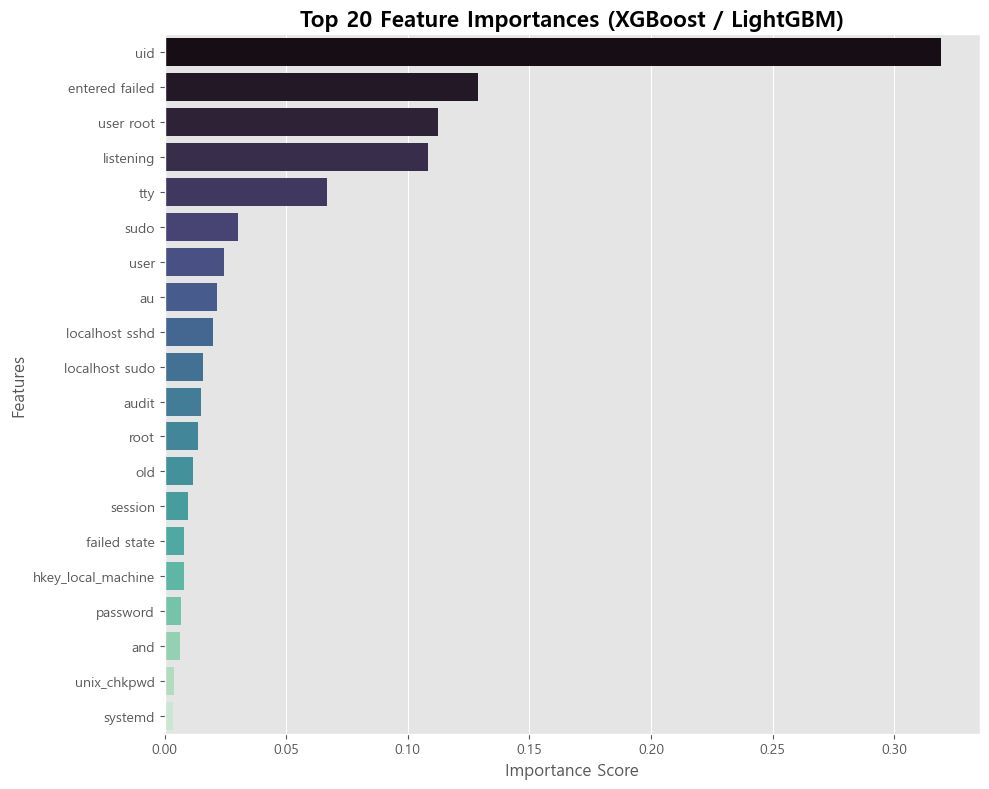

🏆 Top 20 피처 중요도 랭킹 🏆
           Feature  Importance
               uid    0.319270
    entered failed    0.129017
         user root    0.112540
         listening    0.108230
               tty    0.066875
              sudo    0.030261
              user    0.024475
                au    0.021606
    localhost sshd    0.019987
    localhost sudo    0.015693
             audit    0.015154
              root    0.013772
               old    0.011595
           session    0.009548
      failed state    0.007889
hkey_local_machine    0.007823
          password    0.006712
               and    0.006292
       unix_chkpwd    0.003819
           systemd    0.003628


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 폰트 설정 (그래프에서 한글이나 특수문자 깨짐 방지)
# 윈도우 사용자의 경우:
plt.rc('font', family='Malgun Gothic') 
# 맥(Mac) 사용자의 경우 아래 주석을 해제하고 위 줄을 주석 처리하세요:
# plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

# 2. 파이프라인에서 전처리기와 학습된 모델 추출
preprocessor = pipeline.named_steps['preprocessor']
classifier = pipeline.named_steps['classifier']

# 3. 전체 피처 이름 추출 (scikit-learn 1.0 이상 지원)
# TF-IDF 단어들과 추가한 숫자형 컬럼 이름들을 순서대로 모두 가져옵니다.
raw_feature_names = preprocessor.get_feature_names_out()

# (선택) 이름이 'text__login', 'numeric__log_length' 처럼 접두사가 붙어 나오므로 깔끔하게 제거
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# 4. 모델에서 피처 중요도 값 추출
importances = classifier.feature_importances_

# 5. 보기 좋게 데이터프레임으로 묶기
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
})

# 6. 중요도 기준 내림차순 정렬 후 상위 20개 자르기
top20_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# 7. 시각화 (가로 막대 그래프)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top20_df, palette='mako')

# 그래프 꾸미기
plt.title('Top 20 Feature Importances (XGBoost / LightGBM)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

# 그래프 출력
plt.show()

# (보너스) 상위 20개 정확한 수치 텍스트로 출력
print("🏆 Top 20 피처 중요도 랭킹 🏆")
print(top20_df.to_string(index=False))

In [35]:
from sklearn.metrics import f1_score

# 학습 데이터 예측 및 채점
y_train_pred = pipeline.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
print(f"Train Macro F1: {train_f1:.4f}")

Train Macro F1: 0.9610
